# **ANEXO 2 - Código de Programación**

A continuación se incluye el código empleado para el análisis del ejemplo práctico, cuyo objetivo es la clasificación de estudiantes finlandeses similares  en el informe PISA.2022. No obstante, inicialmente se carga todas las librerías necesarias.

**Carga de librerías**

In [ ]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gower
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix, classification_report, silhouette_samples
from kmedoids import fasterpam, pam
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from scipy.stats import shapiro
import time
from kmodes.kprototypes import KPrototypes
from sklearn import tree
from PIL import Image

## **1. Creación de la Base de Datos y Preprocesamiento**


### 1.1. Carga de los Datos

In [2]:
# Carga del dataset completo de PISA
pisa_global, meta = pyreadstat.read_sav("data_pisa.sav")

# Filtrar y seleccionar las columnas específicas para el análisis
pisa_finlandia = pisa_global[pisa_global['CNT'] == "FIN"][[
    "PV1MCSS", "PV1MCUD", "PV1MPEM", "PV1MPFS", "PV1MPIN", "PV1MPRE",
    "ST005Q01JA", "ST007Q01JA", "ST255Q01JA", "ST254Q02JA", "ST254Q03JA",
    "ST004D01T", "REPEAT"
]].copy()

### 1.2. Limpieza y Adecuación de los Datos

In [3]:
# Identificación de los duplicados
duplicados = pisa_finlandia.duplicated().sum()
print(f"\033[1mNúmero de entradas duplicadas: \033[0m{duplicados}\n")
print(pisa_finlandia[pisa_finlandia.duplicated()])

Número de entradas duplicadas: 0

Empty DataFrame
Columns: [PV1MCSS, PV1MCUD, PV1MPEM, PV1MPFS, PV1MPIN, PV1MPRE, ST005Q01JA, ST007Q01JA, ST255Q01JA, ST254Q02JA, ST254Q03JA, ST004D01T, REPEAT]
Index: []


In [4]:
# Comprobación tipo de variables
pisa_finlandia.info()

<class 'pandas.DataFrame'>
RangeIndex: 10239 entries, 171689 to 181927
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PV1MCSS     10239 non-null  float64
 1   PV1MCUD     10239 non-null  float64
 2   PV1MPEM     10239 non-null  float64
 3   PV1MPFS     10239 non-null  float64
 4   PV1MPIN     10239 non-null  float64
 5   PV1MPRE     10239 non-null  float64
 6   ST005Q01JA  9814 non-null   float64
 7   ST007Q01JA  9616 non-null   float64
 8   ST255Q01JA  9997 non-null   float64
 9   ST254Q02JA  9718 non-null   float64
 10  ST254Q03JA  9759 non-null   float64
 11  ST004D01T   10239 non-null  float64
 12  REPEAT      9911 non-null   float64
dtypes: float64(13)
memory usage: 1.0 MB


In [5]:
# Selección variables cualitativas
vars_cualitativas = [
    "ST005Q01JA", "ST007Q01JA", "ST255Q01JA","ST254Q02JA","ST254Q03JA",
    "ST004D01T", "REPEAT"
]

for col in vars_cualitativas:
    # Buscar etiquetas en el archivo .sav
    etiquetas = meta.variable_value_labels.get(col)

    # Incluir etiquetas en la base de datos
    if etiquetas:
        pisa_finlandia[col] = pisa_finlandia[col].replace(etiquetas).astype('category')

pisa_finlandia.info()

<class 'pandas.DataFrame'>
RangeIndex: 10239 entries, 171689 to 181927
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   PV1MCSS     10239 non-null  float64 
 1   PV1MCUD     10239 non-null  float64 
 2   PV1MPEM     10239 non-null  float64 
 3   PV1MPFS     10239 non-null  float64 
 4   PV1MPIN     10239 non-null  float64 
 5   PV1MPRE     10239 non-null  float64 
 6   ST005Q01JA  9814 non-null   category
 7   ST007Q01JA  9616 non-null   category
 8   ST255Q01JA  9997 non-null   category
 9   ST254Q02JA  9718 non-null   category
 10  ST254Q03JA  9759 non-null   category
 11  ST004D01T   10239 non-null  category
 12  REPEAT      9911 non-null   category
dtypes: category(7), float64(6)
memory usage: 550.8 KB


### 1.3. Análisis Descriptivo Inicial

In [6]:
# Estadísticas básicas
pisa_finlandia.describe()

,PV1MCSS,PV1MCUD,PV1MPEM,PV1MPFS,PV1MPIN,PV1MPRE
count,10239.000000,10239.000000,10239.000000,10239.000000,10239.000000,10239.000000
mean,476.308148,474.298990,473.896638,475.681575,478.513907,475.807790
std,97.182854,102.632839,99.934538,100.254093,99.317796,96.908106
min,131.219000,102.876000,171.042000,81.129000,110.289000,98.448000
25%,407.534500,400.798000,401.768500,404.516000,408.803500,407.092000
50%,478.074000,476.364000,473.721000,475.809000,479.759000,477.190000
75%,544.158500,547.237500,545.974000,545.233000,548.587500,545.567500
max,815.128000,863.314000,785.706000,789.532000,823.383000,785.696000


In [7]:
# Tablas de frecuencias
for var in vars_cualitativas:
    conteo = pisa_finlandia[var].value_counts()
    porcentajes = pisa_finlandia[var].value_counts(normalize=True).round(4)*100
    tabla_frecuencias = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': porcentajes})
    
    print(tabla_frecuencias)
    print("\n")

                                       Frecuencia  Porcentaje (%)
ST005Q01JA                                                       
<ISCED level 3.4>                            5469           55.73
<ISCED level 3.3>                            3747           38.18
<ISCED level 2>                               378            3.85
<ISCED level 1>                               120            1.22
She did not complete <ISCED level 1>.         100            1.02


                                      Frecuencia  Porcentaje (%)
ST007Q01JA                                                      
<ISCED level 3.3>                           4793           49.84
<ISCED level 3.4>                           4033           41.94
<ISCED level 2>                              561            5.83
<ISCED level 1>                              136            1.41
He did not complete <ISCED level 1>.          93            0.97


                     Frecuencia  Porcentaje (%)
ST255Q01JA                     

In [8]:
# Inlcuir categoría 'I don't know' como NA
pisa_finlandia['ST254Q02JA'] = pisa_finlandia['ST254Q02JA'].replace("I don't know.", pd.NA)
pisa_finlandia['ST254Q03JA'] = pisa_finlandia['ST254Q03JA'].replace("I don't know.", pd.NA)

## **2. Descripción de la Muestra**
### 2.1. Análisis de Valores Faltantes

In [9]:
def buscar_valores_faltantes(df):
    resultados = {}
    for columna in df.columns:
        resultados[columna] = {
            "Null/NaN/NA": df[columna].isnull().sum(),
            "Cadenas ND": (df[columna ]== "ND").sum(),
            "Cadenas vacías ('')": (df[columna] == "").sum(),
            "Guiones ('-')": (df[columna] == "-").sum(),
            "Puntos ('.')": (df[columna] == ".").sum(),
            "Ceros (0)": (df[columna] == 0).sum(),
            "99": (df[columna] == 99).sum(),
            "999": (df[columna] == 999).sum()
        }
    
    # Se imprimen los resultados en un DataFrame
    resultados_df = pd.DataFrame(resultados).transpose()
    return resultados_df

print(buscar_valores_faltantes(pisa_finlandia))


            Null/NaN/NA  Cadenas ND  Cadenas vacías ('')  Guiones ('-')  \
PV1MCSS               0           0                    0              0   
PV1MCUD               0           0                    0              0   
PV1MPEM               0           0                    0              0   
PV1MPFS               0           0                    0              0   
PV1MPIN               0           0                    0              0   
PV1MPRE               0           0                    0              0   
ST005Q01JA          425           0                    0              0   
ST007Q01JA          623           0                    0              0   
ST255Q01JA          242           0                    0              0   
ST254Q02JA          583           0                    0              0   
ST254Q03JA          545           0                    0              0   
ST004D01T             0           0                    0              0   
REPEAT              328  

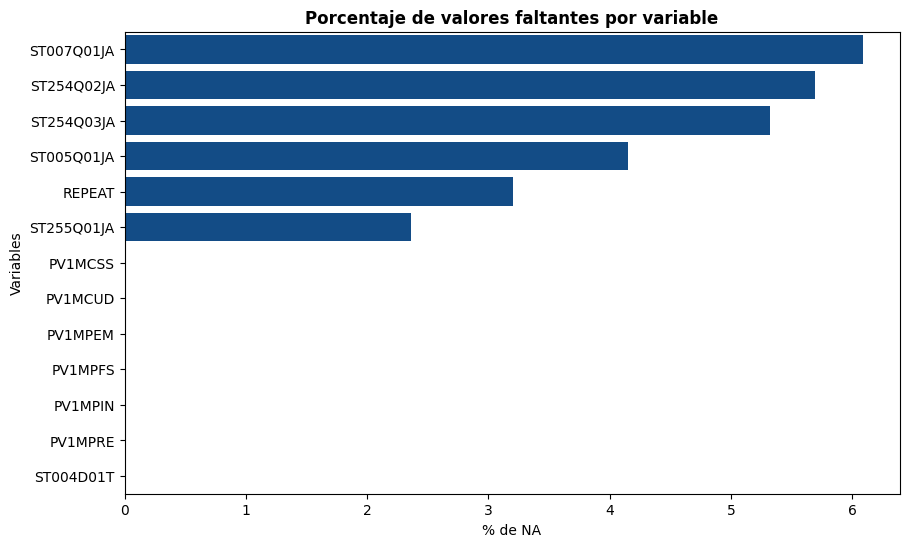

In [10]:
# Cálculo gráfico de barras
# Porcentajes
na_porc = (pisa_finlandia.isnull().mean() * 100).sort_values(ascending=False)

# Representación gráfica
plt.figure(figsize=(10,6))
sns.barplot(x=na_porc.values, y=na_porc.index, color = "#004c99")
plt.title("Porcentaje de valores faltantes por variable", fontweight = 'bold')
plt.xlabel("% de NA")
plt.ylabel("Variables")
plt.show()

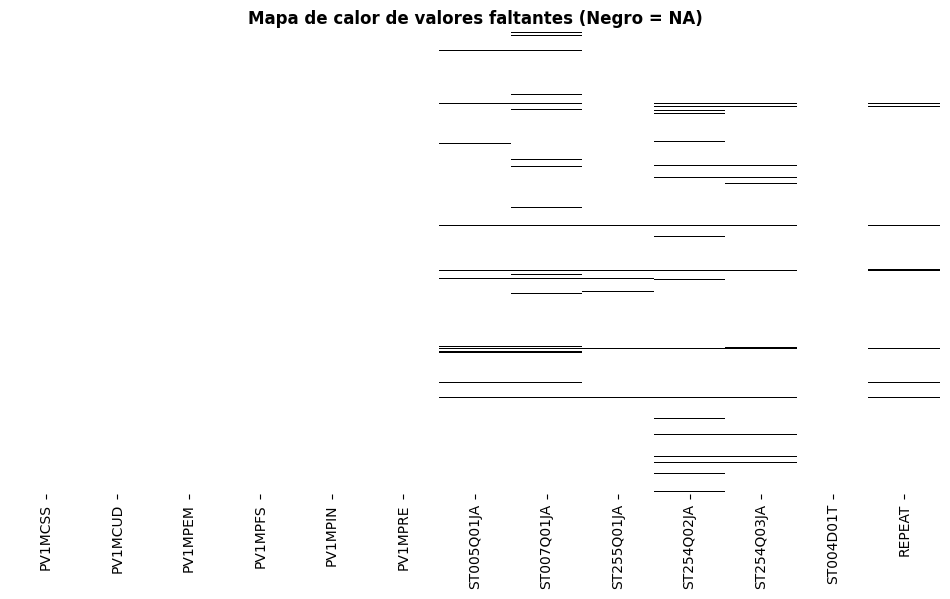

In [11]:
# Estructura de los valores faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(pisa_finlandia.isnull(), cbar=False, yticklabels=False, cmap = "Greys")
plt.title("Mapa de calor de valores faltantes (Negro = NA)", fontweight = 'bold')
plt.xticks(rotation = 90)
plt.show()

In [12]:
datos_finlandia = pisa_finlandia.dropna()

### 2.2. Recodificación de las Variables del Estudio

In [13]:
# Diccionario con las nuevas etiquetas de las variables
diccionario_nombres = {
    "PV1MCSS": "Mat_Espacio_Forma", 
    "PV1MCUD": "Mat_Incertidumbre_Datos",
    "PV1MPEM": "Mat_Empleo_Conceptos", 
    "PV1MPFS": "Mat_Formulacion_Matematica",
    "PV1MPIN": "Mat_Interpretacion_Evaluacion",
    "PV1MPRE": "Mat_Razonamiento",
    "ST005Q01JA": "Edu_Madre", 
    "ST007Q01JA": "Edu_Padre",
    "ST255Q01JA": "Libros_Casa", 
    "ST254Q02JA": "Posesion_Ordenador", 
    "ST254Q03JA": "Posesion_Portátil",
    "ST004D01T": "Genero", 
    "REPEAT": "Repetidor"
}

# Cambio nombre de las variables
datos_finlandia = datos_finlandia.rename(columns = diccionario_nombres)

In [14]:
# Recodificación de las categorías de las variables cuantitativas
# Educación de los padres
map_edu = {
    "<ISCED level 3.3>" : "Secundaria superior",
    "<ISCED level 3.4>" : "Postsecundaria no universitaria",
    "<ISCED level 2>": "Secundaria inferior",
    "<ISCED level 1>": "Primaria",
    "He did not complete <ISCED level 1>.": "Sin estudios",
    "She did not complete <ISCED level 1>.": "Sin estudios"
}

# Libros en casa
map_libros = {
    "1-10 books": "1-10 libros",
    "11-25 books": "11-25 libros",
    "26-100 books": "26-100 libros",
    "101-200 books": "101-200 libros",
    "201-500 books": "201-500 libros",
    "More than 500 books": "Más de 500 libros",
    "There are no books.": "No hay ningun libro"
}

# Ordenadores sobremesa y portátiles
map_posesion = {
    "None": "Ninguno",
    "1 or 2": "1-2",
    "3 - 5": "3-5",
    "More than 5": "Más de 5"
}

# Género
map_genero = {
    "Male": "Hombre",
    "Female": "Mujer"
}

# Repetidor
map_repeat = {
    "Never repeated": "Nunca ha repetido",
    "Repeated at lease once": "Ha repetido al menos una vez"
}

# Inclusión de las variables
datos_finlandia['Edu_Madre'] = datos_finlandia['Edu_Madre'].astype(str).replace(map_edu)
datos_finlandia['Edu_Padre'] = datos_finlandia['Edu_Padre'].astype(str).replace(map_edu)
datos_finlandia['Libros_Casa'] = datos_finlandia['Libros_Casa'].astype(str).replace(map_libros)
datos_finlandia['Posesion_Ordenador'] = datos_finlandia['Posesion_Ordenador'].astype(str).replace(map_posesion)
datos_finlandia['Posesion_Portátil'] = datos_finlandia['Posesion_Portátil'].astype(str).replace(map_posesion)
datos_finlandia['Genero'] = datos_finlandia['Genero'].astype(str).replace(map_genero)
datos_finlandia['Repetidor'] = datos_finlandia['Repetidor'].astype(str).replace(map_repeat)

# Conversión variables categórica
datos_finlandia = datos_finlandia.apply(lambda col: col.astype('category') if col.dtypes == 'str' else col)

### 2.3 Análisis Univariante

In [15]:
# Organización variable para la visualización
datos_finlandia_r = datos_finlandia.copy()
# Ordenar las categorias de las variables ordinales
orden_educacion = ['Sin estudios', 'Primaria','Secundaria inferior', 'Secundaria superior', 'Postsecundaria no universitaria']
orden_libros = ['No hay ningun libro', '1-10 libros', '11-25 libros', '26-100 libros', '101-200 libros', '201-500 libros', 'Más de 500 libros']
orden_posesion = ['Ninguno', '1-2', '3-5', 'Más de 5']

# Orden correcto por variable
datos_finlandia_r['Edu_Madre'] = pd.Categorical(datos_finlandia_r['Edu_Madre'], categories=orden_educacion, ordered=True)
datos_finlandia_r['Edu_Padre'] = pd.Categorical(datos_finlandia_r['Edu_Padre'], categories=orden_educacion, ordered=True)
datos_finlandia_r['Libros_Casa'] = pd.Categorical(datos_finlandia_r['Libros_Casa'], categories=orden_libros, ordered=True)
datos_finlandia_r['Posesion_Ordenador'] = pd.Categorical(datos_finlandia_r['Posesion_Ordenador'], categories=orden_posesion, ordered=True)
datos_finlandia_r['Posesion_Portátil'] = pd.Categorical(datos_finlandia_r['Posesion_Portátil'], categories=orden_posesion, ordered=True)

**Variables cualitativas**


Distribución de: Edu_Madre
                        Categorías  Frecuencias  Porcentaje (%)
0  Postsecundaria no universitaria         5121           56.62
1              Secundaria superior         3430           37.92
2              Secundaria inferior          321            3.55
3                         Primaria           98            1.08
4                     Sin estudios           75            0.83


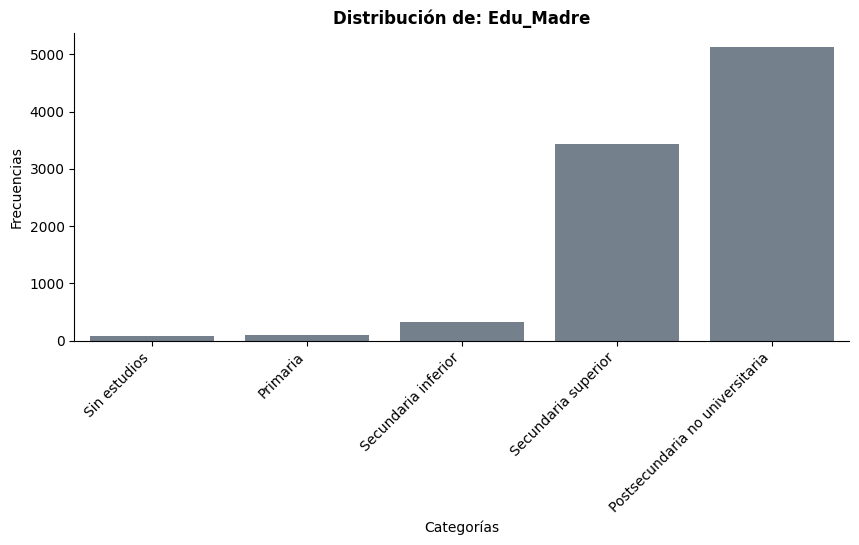


Distribución de: Edu_Padre
                        Categorías  Frecuencias  Porcentaje (%)
0              Secundaria superior         4521           49.98
1  Postsecundaria no universitaria         3817           42.20
2              Secundaria inferior          516            5.70
3                         Primaria          116            1.28
4                     Sin estudios           75            0.83


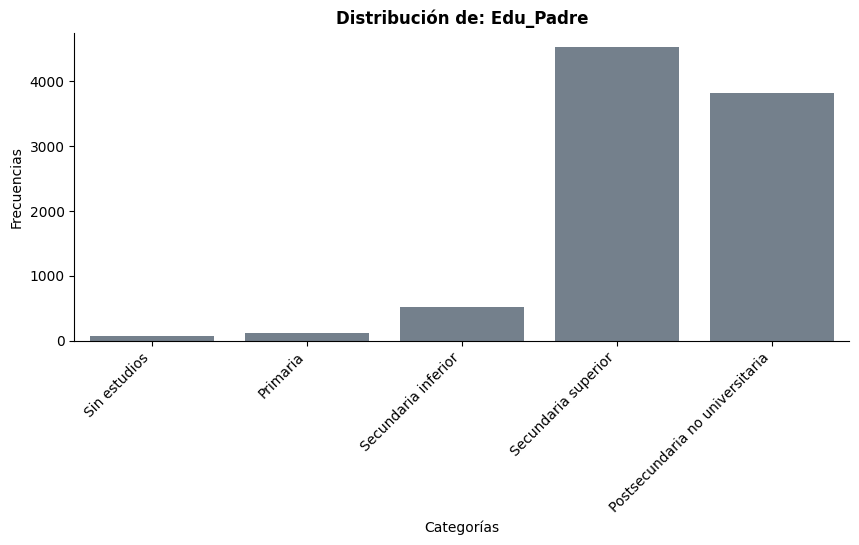


Distribución de: Libros_Casa
            Categorías  Frecuencias  Porcentaje (%)
0        26-100 libros         3085           34.11
1       101-200 libros         1684           18.62
2         11-25 libros         1392           15.39
3       201-500 libros         1246           13.78
4          1-10 libros         1083           11.97
5    Más de 500 libros          394            4.36
6  No hay ningun libro          161            1.78


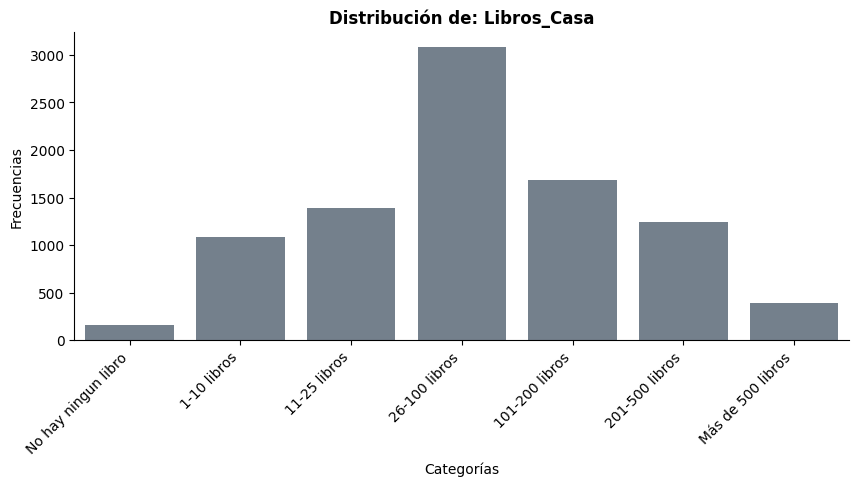


Distribución de: Posesion_Ordenador
  Categorías  Frecuencias  Porcentaje (%)
0        1-2         5305           58.65
1    Ninguno         2740           30.29
2        3-5          927           10.25
3   Más de 5           73            0.81


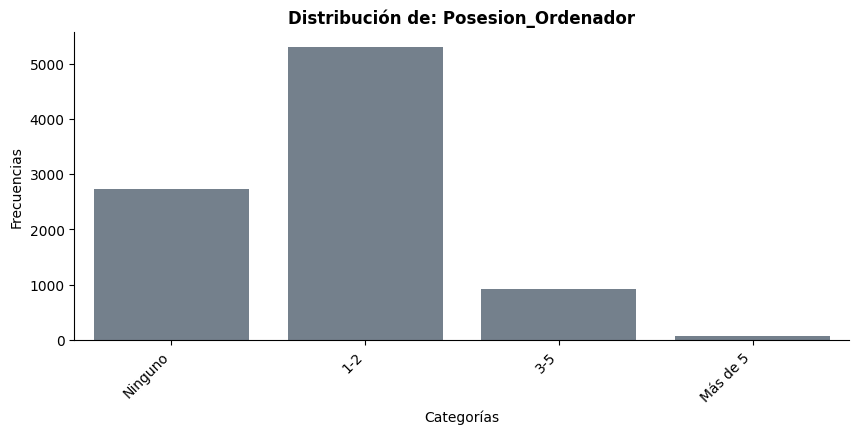


Distribución de: Posesion_Portátil
  Categorías  Frecuencias  Porcentaje (%)
0        1-2         4895           54.12
1        3-5         3513           38.84
2    Ninguno          346            3.83
3   Más de 5          291            3.22


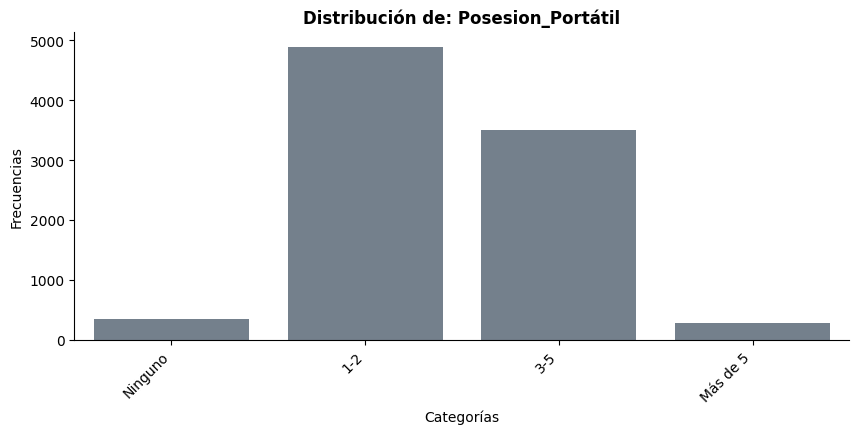


Distribución de: Genero
  Categorías  Frecuencias  Porcentaje (%)
0     Hombre         4528           50.06
1      Mujer         4517           49.94


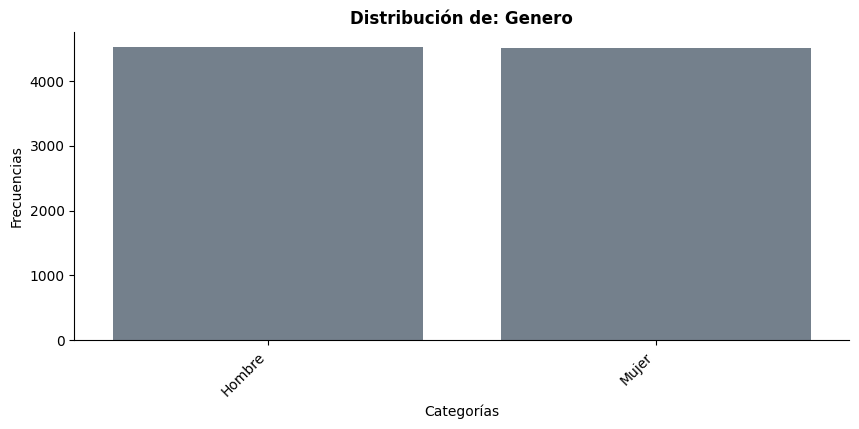


Distribución de: Repetidor
                     Categorías  Frecuencias  Porcentaje (%)
0             Nunca ha repetido         8746           96.69
1  Ha repetido al menos una vez          299            3.31


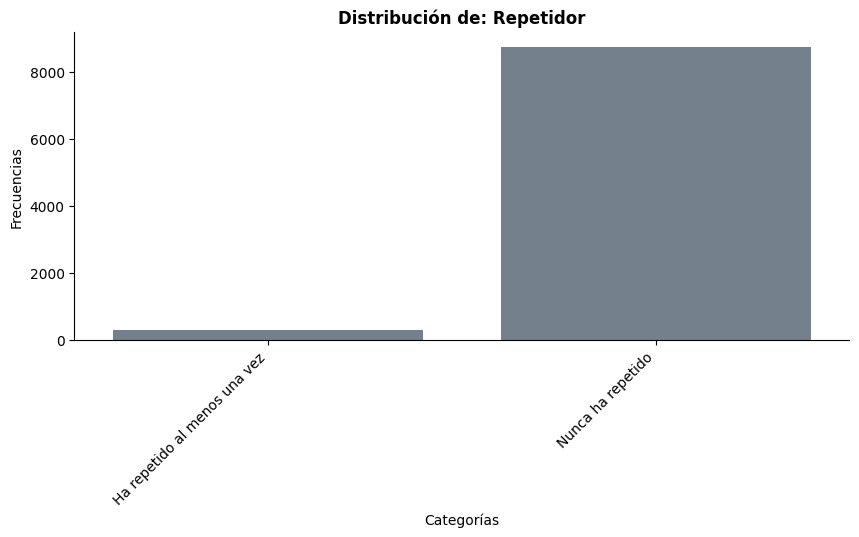

In [16]:
# Selección de las variables cualitativas
vcualitativas = datos_finlandia_r.select_dtypes(include = ['category']).columns

# Tabla + gráfico
for variable in vcualitativas:

    # Tabla de frecuencias
    frecuencias = datos_finlandia_r[variable].value_counts(dropna = False).reset_index()
    frecuencias.columns = ['Categorías','Frecuencias']

    total = frecuencias['Frecuencias'].sum()
    frecuencias['Porcentaje (%)'] = (frecuencias['Frecuencias'] / total * 100).round(2)

    print(f"\n\033[1mDistribución de: {variable}\033[0m")
    print(frecuencias)

    # Gráfico de barras
    plt.figure(figsize=(10, 4))
    sns.countplot(data=datos_finlandia_r, x=variable, color ="slategrey")
    plt.title(f"Distribución de: {variable}", fontweight='bold')
    plt.xlabel("Categorías")
    plt.ylabel("Frecuencias")
    plt.xticks(rotation=45, ha='right')
    sns.despine()
    plt.show()

**Variables cuantitativas**

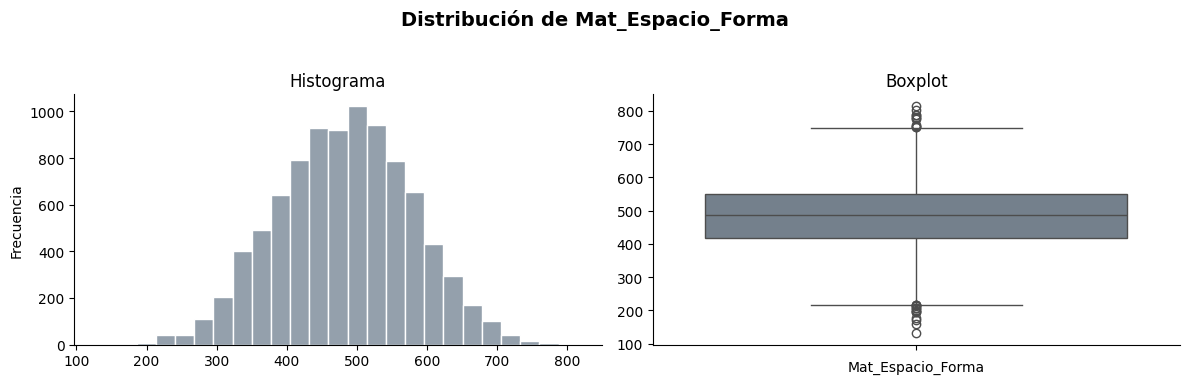

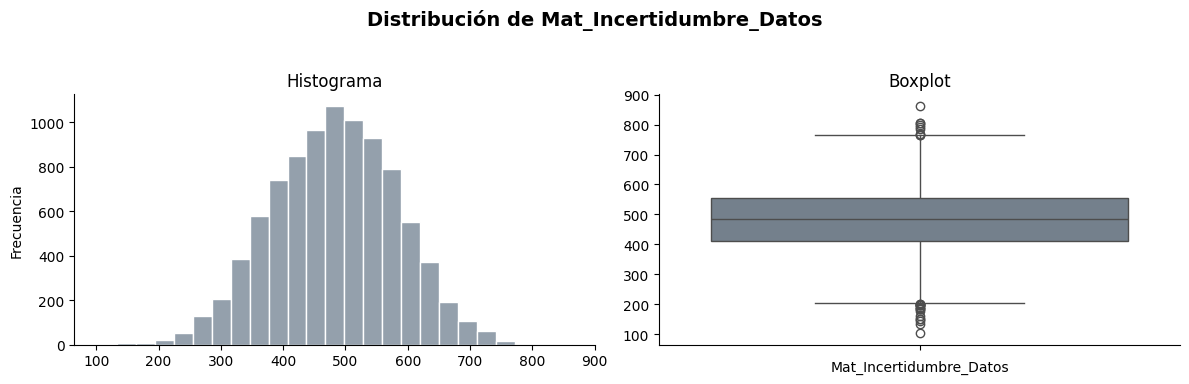

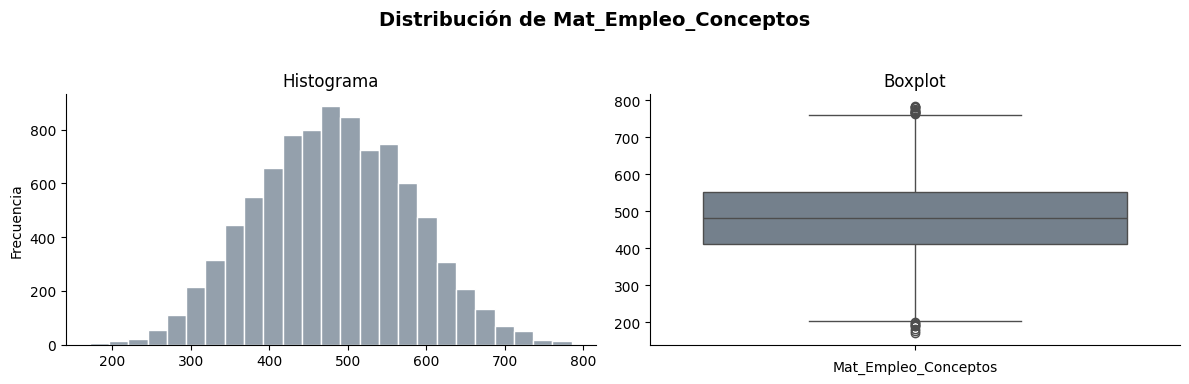

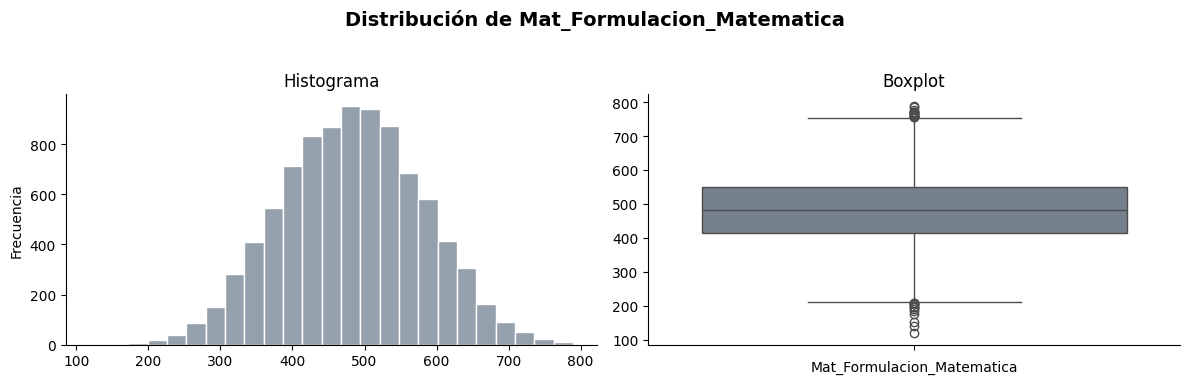

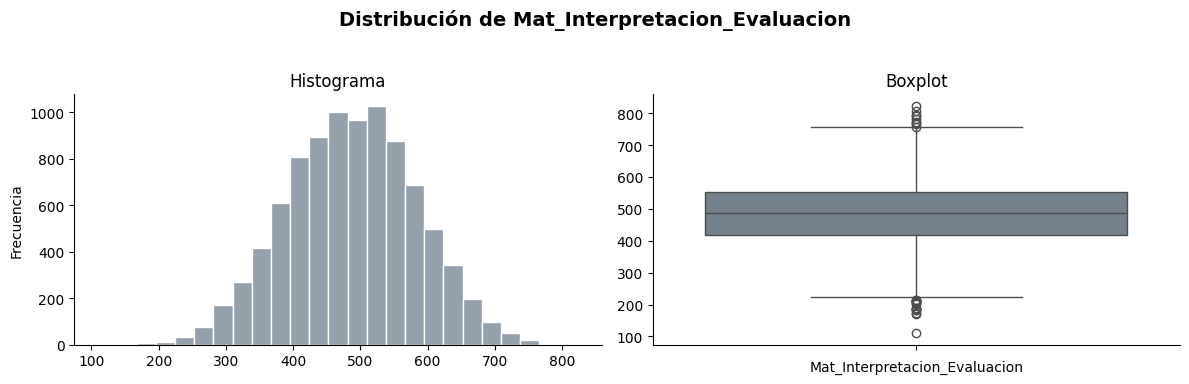

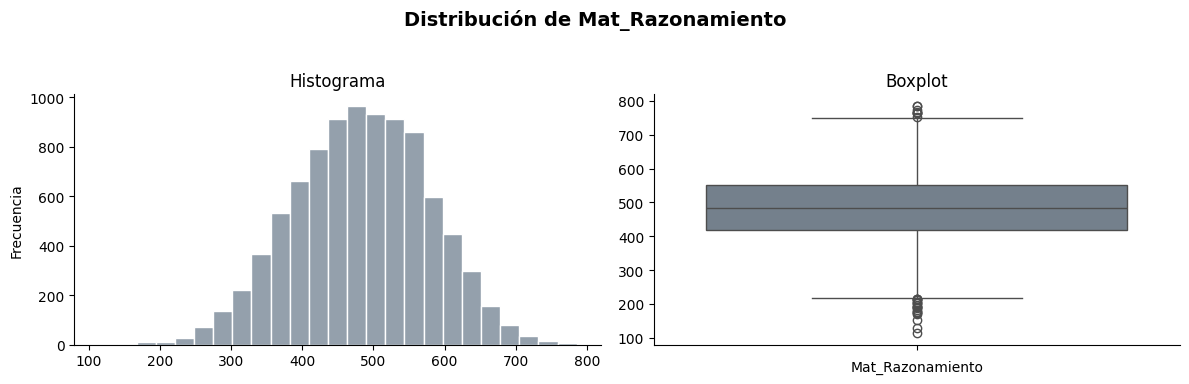

In [17]:
# Selección de variables numéricas
vcuantitativas = datos_finlandia_r.select_dtypes(include = ['number']).columns

# Tabla + Gráfico
for var in vcuantitativas:
    # Histograma
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Distribución de {var}", fontweight = 'bold', fontsize = 14)
    sns.histplot(data=datos_finlandia_r, x=var, bins=25, color="slategrey",
                 edgecolor="white", kde=False, ax=axes[0])
    axes[0].set_title("Histograma")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(data=datos_finlandia_r, y=var, color="slategrey", ax=axes[1])
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("")
    axes[1].set_xlabel(var)
    sns.despine()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [18]:
# Número de alumnos superiores o inferiores a un alumno medio
for var in vcuantitativas:
    Q1 = datos_finlandia_r[var].quantile(0.25)
    Q3 = datos_finlandia_r[var].quantile(0.75)
    RIC = Q3 - Q1
    limite_inf = Q1 - 1.5 * RIC
    limite_sup = Q3 + 1.5 * RIC

    superiores = datos_finlandia_r[datos_finlandia_r[var] > limite_sup][var].count()
    inferiores = datos_finlandia_r[datos_finlandia_r[var] < limite_inf][var].count()

    print(f"\033[1m{var}:\033[0m")
    print(f" - Rendimiento superior: {superiores}")
    print(f" - Rendimiento inferior: {inferiores}")

Mat_Espacio_Forma:
 - Rendimiento superior: 11
 - Rendimiento inferior: 14
Mat_Incertidumbre_Datos:
 - Rendimiento superior: 9
 - Rendimiento inferior: 17
Mat_Empleo_Conceptos:
 - Rendimiento superior: 13
 - Rendimiento inferior: 9
Mat_Formulacion_Matematica:
 - Rendimiento superior: 15
 - Rendimiento inferior: 14
Mat_Interpretacion_Evaluacion:
 - Rendimiento superior: 9
 - Rendimiento inferior: 16
Mat_Razonamiento:
 - Rendimiento superior: 8
 - Rendimiento inferior: 20


### 2.4. Análisis Multivariante

**Variables cuantitativas**

In [19]:
resultados_normalidad = []

for col in vcuantitativas:
    stat, p = shapiro(datos_finlandia_r[col])
    resultados_normalidad.append({
        "Variable" : col,
        "Shapiro_W": round(stat, 4),
        "p-value": round(p, 4),
        "Normal": p > 0.05
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
df_normalidad

c:\Users\paula\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9045.
  res = hypotest_fun_out(*samples, **kwds)


,Variable,Shapiro_W,p-value,Normal
0,Mat_Espacio_Forma,0.9991,0.0001,False
1,Mat_Incertidumbre_Datos,0.9990,0.0000,False
2,Mat_Empleo_Conceptos,0.9984,0.0000,False
3,Mat_Formulacion_Matematica,0.9991,0.0001,False
4,Mat_Interpretacion_Evaluacion,0.9991,0.0001,False
5,Mat_Razonamiento,0.9986,0.0000,False


In [20]:
# Calculo de las matrices de correlación de Pearson y Spearman
matriz_pearson = datos_finlandia_r[vcuantitativas].corr(method = 'pearson')
matriz_spearman = datos_finlandia_r[vcuantitativas].corr(method = 'spearman')

# Creamos una lista por pares de variables
lista_pearson = matriz_pearson.unstack().reset_index() # Crear listado e incluir como columna
lista_spearman = matriz_spearman.unstack().reset_index()

# Unificar nombre de las columnas
lista_pearson.columns = ['Variable 1', 'Variable 2', 'Pearson']
lista_spearman.columns = ['Variable 1', 'Variable 2', 'Spearman']

# Fusión en una tabla de Pearson y Spearman
tabla_comparacion = pd.merge(lista_pearson, lista_spearman, on = ['Variable 1', 'Variable 2'])

# Eliminar comparaciones duplicadas
tabla_comparacion = tabla_comparacion[tabla_comparacion['Variable 1'] < tabla_comparacion['Variable 2']].reset_index(drop = True)

# Diferencia absoluta entre coeficientes
tabla_comparacion['Diferencia Absoluta'] = (tabla_comparacion['Pearson'] - tabla_comparacion['Spearman']).abs()

# 4 decimales
tabla_comparacion = tabla_comparacion.round(4)

tabla_comparacion


,Variable 1,Variable 2,Pearson,Spearman,Diferencia Absoluta
0,Mat_Espacio_Forma,Mat_Incertidumbre_Datos,0.7808,0.7800,0.0008
1,Mat_Espacio_Forma,Mat_Formulacion_Matematica,0.7355,0.7364,0.0008
2,Mat_Espacio_Forma,Mat_Interpretacion_Evaluacion,0.7403,0.7399,0.0004
3,Mat_Espacio_Forma,Mat_Razonamiento,0.7552,0.7583,0.0030
4,Mat_Incertidumbre_Datos,Mat_Interpretacion_Evaluacion,0.8042,0.8050,0.0009
5,Mat_Incertidumbre_Datos,Mat_Razonamiento,0.7942,0.7962,0.0020
6,Mat_Empleo_Conceptos,Mat_Espacio_Forma,0.7537,0.7544,0.0007
7,Mat_Empleo_Conceptos,Mat_Incertidumbre_Datos,0.8073,0.8111,0.0037
8,Mat_Empleo_Conceptos,Mat_Formulacion_Matematica,0.8631,0.8614,0.0017
9,Mat_Empleo_Conceptos,Mat_Interpretacion_Evaluacion,0.8741,0.8745,0.0004


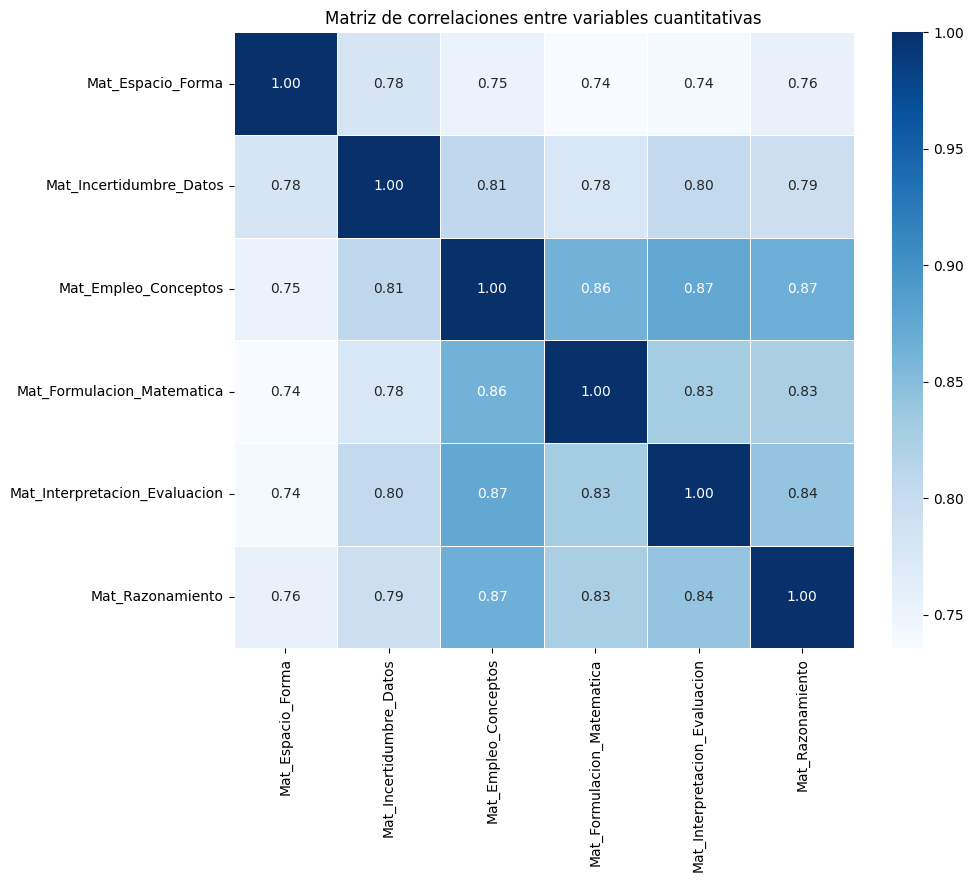

In [21]:
# Heatmap correlaciones Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_pearson, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones entre variables cuantitativas")
plt.show()

**Variables cualitativas**

In [22]:
# Tabla de contingencia con cruce de factores
for i in range(len(vcualitativas)-1):
    for j in range(i+1, len(vcualitativas)):
        print(f"\n\nTabla cruzada: {vcualitativas[i]} vs {vcualitativas[j]}")
        print(pd.crosstab(datos_finlandia[vcualitativas[i]], datos_finlandia[vcualitativas[j]]))




Tabla cruzada: Edu_Madre vs Edu_Padre
Edu_Padre                        Postsecundaria no universitaria  Primaria  \
Edu_Madre                                                                    
Postsecundaria no universitaria                             2995        32   
Primaria                                                      17        26   
Secundaria inferior                                           66        14   
Secundaria superior                                          731        34   
Sin estudios                                                   8        10   

Edu_Padre                        Secundaria inferior  Secundaria superior  \
Edu_Madre                                                                   
Postsecundaria no universitaria                  184                 1894   
Primaria                                          18                   31   
Secundaria inferior                              101                  130   
Secundaria superior         

In [23]:
# Cálculo V de Cramer
def cramer_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n*min(r-1, k-1)))

# Matriz
matriz_cramer = pd.DataFrame(np.zeros((len(vcualitativas), len(vcualitativas))),
                   index = vcualitativas, columns = vcualitativas)

# Calculo coeficiente
for v1 in vcualitativas:
    for v2 in vcualitativas:
        matriz_cramer.loc[v1, v2] = cramer_v(datos_finlandia_r[v1], datos_finlandia_r[v2])

matriz_cramer

,Edu_Madre,Edu_Padre,Libros_Casa,Posesion_Ordenador,Posesion_Portátil,Genero,Repetidor
Edu_Madre,1.000000,0.319010,0.153766,0.054842,0.119765,0.060167,0.155057
Edu_Padre,0.319010,1.000000,0.147911,0.059917,0.127692,0.031482,0.144626
Libros_Casa,0.153766,0.147911,1.000000,0.071886,0.165724,0.071345,0.111684
Posesion_Ordenador,0.054842,0.059917,0.071886,1.000000,0.140835,0.162154,0.038815
Posesion_Portátil,0.119765,0.127692,0.165724,0.140835,1.000000,0.042188,0.091507
Genero,0.060167,0.031482,0.071345,0.162154,0.042188,0.999779,0.031931
Repetidor,0.155057,0.144626,0.111684,0.038815,0.091507,0.031931,0.998271


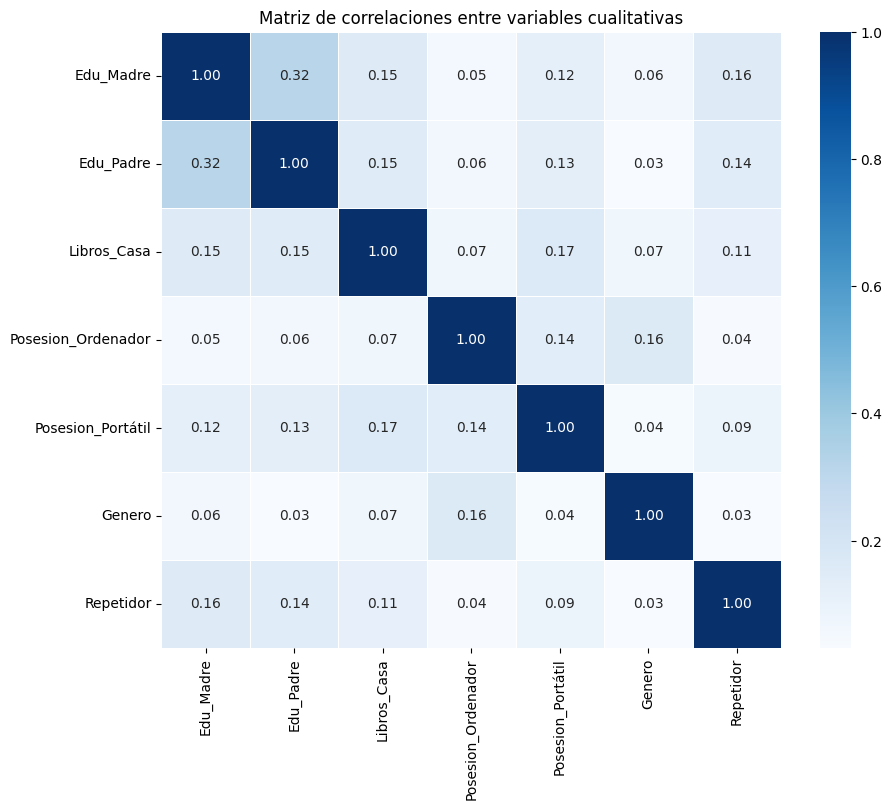

In [24]:
# Heatmap correlaciones Cramer
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_cramer, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlaciones entre variables cualitativas")
plt.show()

## **3. Resultados**

### 3.1. Identificación de la Clasificación de los Alumnos en la Muestra

In [25]:
# Vector variables categoricas
vcualitativas = datos_finlandia.select_dtypes(include = ['category','object']).columns
es_categorica = [col in vcualitativas for col in datos_finlandia.columns]

# Matriz de distancias Gower
dist_Gower = gower.gower_matrix(datos_finlandia, cat_features = es_categorica)
print(dist_Gower)

[[0.         0.34956476 0.3198435  ... 0.4403064  0.50722134 0.18164714]
 [0.34956476 0.         0.2831942  ... 0.32818452 0.31672588 0.35154015]
 [0.3198435  0.2831942  0.         ... 0.34643707 0.26769564 0.3088191 ]
 ...
 [0.4403064  0.32818452 0.34643707 ... 0.         0.29768416 0.28314364]
 [0.50722134 0.31672588 0.26769564 ... 0.29768416 0.         0.4961969 ]
 [0.18164714 0.35154015 0.3088191  ... 0.28314364 0.4961969  0.        ]]


**Comparación de métodos**

In [28]:
# Tabla para introducir todos los métodos
tabla_comparativa_metodos = []

# k para comparar los métodos
k = 4

In [29]:
# K - Prototypes
# Indicies variables cualtiativas
df_proto = datos_finlandia.copy() # Para no variar la matriz de datos original
vcualitativas = df_proto.select_dtypes(include = ['object','category']).columns.tolist()
indices_cualitativas = [df_proto.columns.get_loc(col) for col in vcualitativas]

# Semilla para garantizar la reproducción
np.random.seed(42)

# Medir el coste computacional
incio_kp = time.time()

# Modelo k-prototypes
kproto = KPrototypes(n_clusters= k, init='Huang', n_init = 5, verbose=0)
clusters_kp = kproto.fit_predict(df_proto.to_numpy(), categorical = indices_cualitativas)

# Fin del tiempo
fin_kp = time.time()

# Evaluación estructura de los clústers, Silhouette
sil_kp = silhouette_score(dist_Gower, clusters_kp, metric = 'precomputed')

tabla_comparativa_metodos.append({
    "Método" : "K-prototypes",
    "Tiempo ejecución (s)": round(fin_kp - incio_kp, 4),
    "Silhouette": round(sil_kp, 4),
    "Pérdida": round(kproto.cost_, 4)
})

In [30]:
# Función para evaluar PAM y FASTPAM
def evaluar(metodo, nombre):
    # Semilla
    np.random.seed(42)
    # Inicio coste computacional
    inicio = time.time()
    # Modelo
    modelo = metodo(dist_Gower, k)
    # Fin coste computacional
    fin = time.time()

    tabla_comparativa_metodos.append({
        "Método": nombre,
        "Tiempo ejecución (s)": round(fin - inicio, 4),
        "Silhouette": round(silhouette_score(dist_Gower, modelo.labels, metric = 'precomputed'), 4),
        "Pérdida": round(modelo.loss, 4)
    })

evaluar(pam, "PAM")
evaluar(fasterpam, "FASTPAM")

In [31]:
 # CLARA y FASTCLARA
def evaluar_CLARA_FASTCLARA(n_muestras, nombre):
    # Incio coste computacional
    inicio = time.time()
    n_obs = dist_Gower.shape[0] # Tamaño base de datos
    tam_muestra = min(n_obs, 40 + 2 * k) # Selección del tamaño de la muestra

    # Incialización del coste y las mejores etiquetas del modelo
    mejor_loss = np.inf
    mejores_etiquetas = None

    # Bucle de aplicar PAM o FASTPAM a las submuestras
    for i in range(n_muestras):
        indices = np.random.choice(n_obs, tam_muestra, replace = False) # Selección aleatoria de individuos
        sub_matriz = dist_Gower[indices][:, indices] # Matriz de Gower correspondiente a la submuestra
        
        # Método CLARA o FASTCLARA
        if nombre == 'CLARA':
            # Método CLARA con PAM
            np.random.seed(42) # semilla
            resultado = pam(sub_matriz, k)
            medodides_en_muestra = resultado.medoids # medoides
        else:
            # Mëtodo FASTCLARA con FASTPAM
            np.random.seed(42)
            resultado = fasterpam(sub_matriz, k)
            medodides_en_muestra = resultado.medoids
        
        medoides_indices_globales = indices[medodides_en_muestra] # Posiciones de los medoides locales
        distancia_a_medoides = dist_Gower[:, medoides_indices_globales] # Calculo de la distancia del alumno a su medoide
        etiquetas_actuales = np.argmin(distancia_a_medoides, axis = 1) # Asignación cada alumno al medoide más próximo
        loss_actual = np.sum(np.min(distancia_a_medoides, axis = 1)) # Criterio parada

        # Solución que minimiza el coste
        if loss_actual < mejor_loss:
            mejor_loss = loss_actual
            mejores_etiquetas = etiquetas_actuales
    
    # Fin coste computacional
    fin = time.time()
    
    # Inclusión en la tabla
    tabla_comparativa_metodos.append({
        "Método": nombre,
        "Tiempo ejecución (s)": round(fin - inicio, 4),
        "Silhouette": round(silhouette_score(dist_Gower, mejores_etiquetas, metric = 'precomputed'), 4),
        "Pérdida": round(mejor_loss, 4)
    })

evaluar_CLARA_FASTCLARA(n_muestras=5, nombre = "CLARA")
evaluar_CLARA_FASTCLARA(n_muestras=5, nombre = "FASTCLARA")

In [32]:
tabla_comparativa_metodos = pd.DataFrame(tabla_comparativa_metodos)
tabla_comparativa_metodos

,Método,Tiempo ejecución (s),Silhouette,Pérdida
0,K-prototypes,104.0992,0.0505,1.280604e+08
1,PAM,10.4548,0.1433,1.721115e+03
2,FASTPAM,1.9315,0.1436,1.703295e+03
3,CLARA,0.0192,0.1253,1.859090e+03
4,FASTCLARA,0.0131,0.1176,1.933765e+03


**Aplicación del método**

In [33]:
# k = 2
np.random.seed(42)
km2 = fasterpam(dist_Gower, 2)
datos_finlandia['cluster_2'] = km2.labels
print("\n\033[1mDistribución para k=2\033[0m")
print(datos_finlandia['cluster_2'].value_counts())

# k = 6
np.random.seed(42)
km6 = fasterpam(dist_Gower, 6)
datos_finlandia['cluster_6'] = km6.labels
print("\033[0mDistribución para k=6\033[0m")
print(datos_finlandia['cluster_6'].value_counts())

# Medoides para k=6
medoides_k6 = datos_finlandia.iloc[km6.medoids]
print("\n\033[1mPerfil de los medodides para k=6\033[0m")
print(medoides_k6)


Distribución para k=2
cluster_2
1    4562
0    4483
Name: count, dtype: int64
Distribución para k=6
cluster_6
1    1899
2    1742
0    1544
5    1327
3    1291
4    1242
Name: count, dtype: int64

Perfil de los medodides para k=6
        Mat_Espacio_Forma  Mat_Incertidumbre_Datos  Mat_Empleo_Conceptos  \
172354            476.107                  460.188               478.819   
178953            523.527                  491.024               506.923   
173885            548.923                  505.739               542.589   
172824            459.263                  436.738               444.286   
177334            530.083                  572.503               513.201   
173764            401.703                  380.480               443.046   

        Mat_Formulacion_Matematica  Mat_Interpretacion_Evaluacion  \
172354                     445.456                        448.032   
178953                     477.642                        488.540   
173885                     52

In [34]:
# Extraer etiquetas
labels = datos_finlandia['cluster_6'].values

# Calcular Silhouette
silhouette_avg = silhouette_score(dist_Gower, labels, metric = "precomputed")

print("Silhouette medio para k=6:", silhouette_avg)

silhouette_vals = silhouette_samples(dist_Gower, labels, metric = "precomputed")

datos_finlandia['silhouette'] = silhouette_vals

# Silhouette medio por clúster
silhouette_por_cluster = datos_finlandia.groupby('cluster_6')['silhouette'].mean()
print("\nSilhouette medio por clúster:")
print(silhouette_por_cluster)

Silhouette medio para k=6: 0.1490175426006317

Silhouette medio por clúster:
cluster_6
0    0.150464
1    0.147033
2    0.191683
3    0.189076
4    0.093298
5    0.107344
Name: silhouette, dtype: float32


## **3.2. Interpretación de los Factores Asociados a la Clasificación**

In [36]:
# Selección matriz de datos independientes y variable dependiente
X = datos_finlandia.drop(['cluster_2','cluster_6','silhouette'], axis = 1, errors = 'ignore')
X_encoded = pd.get_dummies(X, drop_first = True)
y = datos_finlandia['cluster_6']

# Separación de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size = 0.2, random_state=42, stratify = y
)

# Entrenamiento del árbol
clasificacion_final = DecisionTreeClassifier(max_depth = 4, random_state=42)
clasificacion_final.fit(X_train, y_train)

# Evaluación del árbol
y_pred_test = clasificacion_final.predict(X_test)

# Métricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_test)}")
print("\n Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_test))
print("\n Informe:")
print(classification_report(y_test, y_pred_test))

Accuracy: 0.699281370923162

 Matriz de confusión:
[[227  30  13  17  11  11]
 [  8 306  47   0  12   7]
 [ 22   2 241  33  51   0]
 [  0  23  50 183   2   0]
 [ 15   3   1  30 158  41]
 [  0  48  10  20  37 150]]

 Informe:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       309
           1       0.74      0.81      0.77       380
           2       0.67      0.69      0.68       349
           3       0.65      0.71      0.68       258
           4       0.58      0.64      0.61       248
           5       0.72      0.57      0.63       265

    accuracy                           0.70      1809
   macro avg       0.70      0.69      0.69      1809
weighted avg       0.70      0.70      0.70      1809



In [37]:
# Importancia de las variables
importancias = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Importancia': clasificacion_final.feature_importances_
}).sort_values('Importancia', ascending=False)
importancias.head(10)

,Variable,Importancia
12,Edu_Padre_Secundaria superior,0.250567
26,Genero_Mujer,0.209925
23,Posesion_Portátil_3-5,0.207909
22,Posesion_Ordenador_Ninguno,0.186204
17,Libros_Casa_26-100 libros,0.106375
8,Edu_Madre_Secundaria superior,0.036318
11,Edu_Padre_Secundaria inferior,0.002702
0,Mat_Espacio_Forma,0.000000
16,Libros_Casa_201-500 libros,0.000000
25,Posesion_Portátil_Ninguno,0.000000


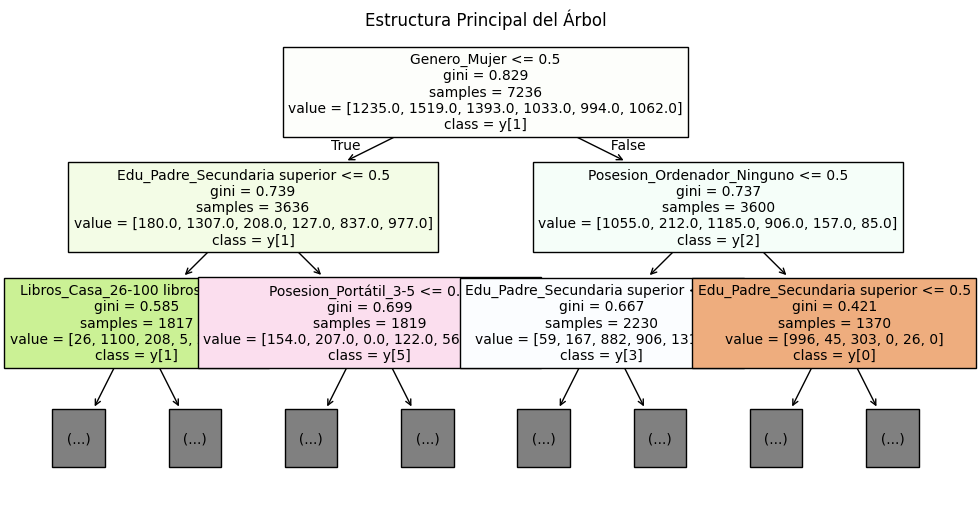

In [39]:
plt.figure(figsize = (12, 6))
tree.plot_tree(clasificacion_final,
               max_depth= 2,
               feature_names= X_encoded.columns,
               class_names = True,
               filled = True,
               fontsize = 10)

plt.title("Estructura Principal del Árbol")
plt.show()

In [47]:
# Imágen completa del árbol
nombre_archivo = "arbol_completo_tfg.png"
plt.figure(figsize=(80, 25))
tree.plot_tree(clasificacion_final,
               feature_names= X_encoded.columns,
               class_names= True,
               filled= True,
               impurity = False,
               fontsize= 7)
plt.savefig(nombre_archivo, dpi=100, bbox_inches='tight')
plt.close()

# Carga de la imagen y troceado
img = Image.open(nombre_archivo)
ancho, alto = img.size
cuarto = ancho // 4

for i in range(4):
    # Definción recuadro de corte
    izquierda = i * cuarto
    derecha = (i + 1) * cuarto
    # Para que no se corten nodos
    if i > 0: izquierda -= 100

    trozo = img.crop((izquierda, 0, derecha, alto))
    trozo.save(f"arbol_parte_{i+1}.png")
    print(f"Parte {i+1} creada con éxito")

Parte 1 creada con éxito
Parte 2 creada con éxito
Parte 3 creada con éxito
Parte 4 creada con éxito


In [48]:
# Reglas de clasificación
reglas = export_text(clasificacion_final, feature_names= list(X_encoded.columns))
print(reglas)

|--- Genero_Mujer <= 0.50
|   |--- Edu_Padre_Secundaria superior <= 0.50
|   |   |--- Libros_Casa_26-100 libros <= 0.50
|   |   |   |--- Posesion_Portátil_3-5 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Posesion_Portátil_3-5 >  0.50
|   |   |   |   |--- class: 4
|   |   |--- Libros_Casa_26-100 libros >  0.50
|   |   |   |--- Edu_Padre_Secundaria inferior <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Edu_Padre_Secundaria inferior >  0.50
|   |   |   |   |--- class: 1
|   |--- Edu_Padre_Secundaria superior >  0.50
|   |   |--- Posesion_Portátil_3-5 <= 0.50
|   |   |   |--- Libros_Casa_26-100 libros <= 0.50
|   |   |   |   |--- class: 5
|   |   |   |--- Libros_Casa_26-100 libros >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Posesion_Portátil_3-5 >  0.50
|   |   |   |--- Edu_Madre_Secundaria superior <= 0.50
|   |   |   |   |--- class: 4
|   |   |   |--- Edu_Madre_Secundaria superior >  0.50
|   |   |   |   |--- class: 4
|--- Genero_Mujer >  0.50
|   |--- Posesion_